# Phase 2: Data Preprocessing Pipeline
*(Where we transition from observing the data to actively modifying it for the algorithms).*

## Step 0: Environment Setup & Data Check
Because this is a new notebook, we will quickly re-load our dataset and re-execute our Train/Test Split so our `X_train` and `X_test` variables are fresh and ready in memory.

In [239]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv('../data/raw/train.csv')
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Split data
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== STARTING DATASET SIZES ===")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")

=== STARTING DATASET SIZES ===
X_train shape: (1168, 79)
y_train shape: (1168,)
X_test shape:  (292, 79)


## Step 1: Row-Level Fixes (The Manual Deletions)
In Machine Learning, deleting rows of data is the absolute last resort. We rely on math (Log Transformations and Scaling) to handle normal statistical outliers (like a massive 200,000 sq ft lot).

However, we must manually delete rows if the data is **corrupted** or **violates reality**. 

### The `GrLivArea` Anomaly
`GrLivArea` stands for **Above Grade Living Area**. It is the total finished, heated square footage of the 1st and 2nd floors (strictly excluding the basement and garage). It is the single most important driver of a home's price.

During EDA, we discovered a few massive houses (> 4,000 sq ft) that sold for suspiciously low prices (< $300,000). 
*   **Why we can't use math:** Math can fix a massive house that is very expensive. But these houses are massive AND extremely cheap (likely foreclosures or family sales). This is an inverse correlation. No mathematical transformation can fix an inverse correlation.
*   **The Danger:** If we feed these to the model, it learns a false, broken rule: *"Massive houses are cheap."*
*   **The Fix:** We will use a Boolean Mask to find these specific corrupted transactions and permanently drop them from the **Training set only**.

In [240]:
# --- 1. REMOVE EXTREME OUTLIERS ---

# Create the mask: House is massive (>4000 sq ft) AND unreasonably cheap (<$300,000)
outlier_mask = (X_train['GrLivArea'] > 4000) & (y_train < 300000)

# Apply the mask (The ~ symbol means 'KEEP rows where the mask is FALSE')
X_train = X_train[~outlier_mask]
y_train = y_train[~outlier_mask]

print("=== POST-OUTLIER DELETION SIZES ===")
print(f"Rows deleted from training set: {outlier_mask.sum()}")
print(f"New X_train shape: {X_train.shape}")
print(f"New y_train shape: {y_train.shape}")

=== POST-OUTLIER DELETION SIZES ===
Rows deleted from training set: 2
New X_train shape: (1166, 79)
New y_train shape: (1166,)


## Step 2: Target Variable Transformation
Our EDA confirmed that `SalePrice` is severely right-skewed. We must apply a Log Transformation (`np.log1p`) so the algorithms aren't disproportionately penalized by luxury outliers. 

*(Note: Because this is a transformation rule, we MUST apply it to both the Training and Test sets).* 

Target variables successfully log-transformed.
Original y_train skew: 1.74
New y_train_log skew: 0.13


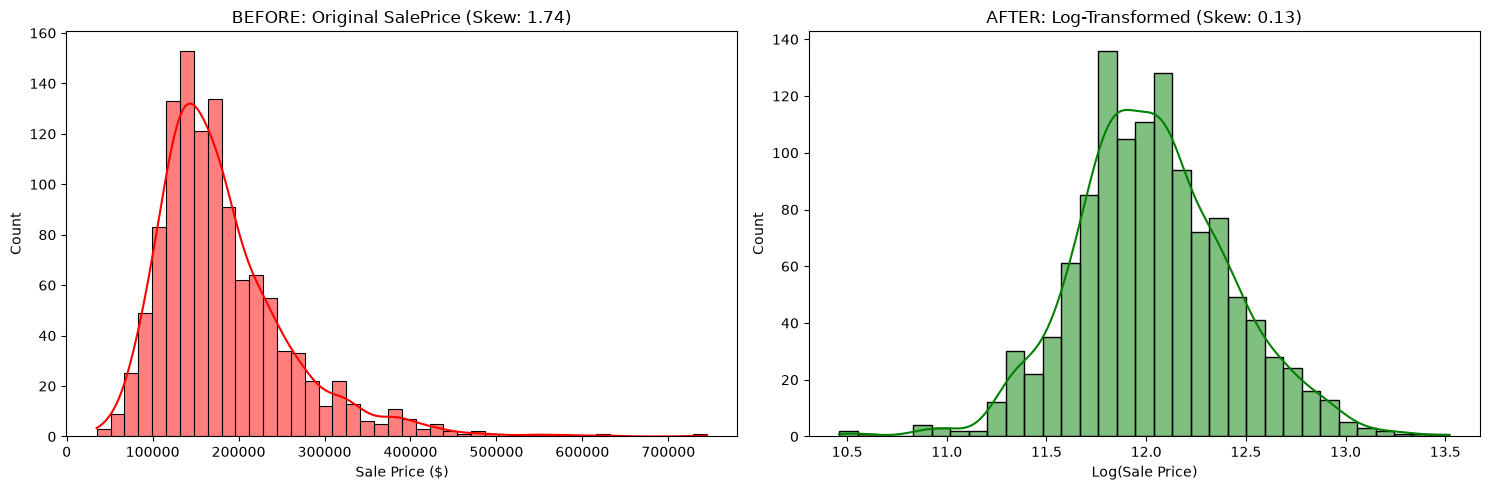

In [241]:
# --- 2. LOG TRANSFORM THE TARGET ---
import seaborn as sns
import matplotlib.pyplot as plt

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Target variables successfully log-transformed.")
print(f"Original y_train skew: {y_train.skew():.2f}")
print(f"New y_train_log skew: {y_train_log.skew():.2f}")

# --- VISUALIZE THE FIX ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Before Plot
sns.histplot(y_train, kde=True, ax=axes[0], color='red')
axes[0].set_title(f'BEFORE: Original SalePrice (Skew: {y_train.skew():.2f})')
axes[0].set_xlabel('Sale Price ($)')

# After Plot
sns.histplot(y_train_log, kde=True, ax=axes[1], color='green')
axes[1].set_title(f'AFTER: Log-Transformed (Skew: {y_train_log.skew():.2f})')
axes[1].set_xlabel('Log(Sale Price)')

plt.tight_layout()
plt.show()

## Handling Missing Values

## Step 3: MNAR Missing Value Strategy (Structural Missingness)
We are now dealing with **Missing Not At Random (MNAR)** data. These are `NaN` values that were left blank on purpose (e.g., leaving `PoolQC` blank because there is no pool).

**How did we select these specific features?**
1. **Domain Knowledge:** The official `data_description.txt` dictionary explicitly states that 'NA' in these columns translates to 'No Pool', 'No Garage', etc.
2. **EDA Pattern Recognition:** In our missingness report, we noticed that all 4 Garage columns had the exact same missing percentage (~5.5%). Random errors don't happen in perfect unison. This proved structurally that if a house lacked a garage, all related columns went blank simultaneously.

### 3.1 Categorical MNAR: Fill with 'None'
Instead of guessing the Mode (which would magically build pools in backyards that don't have them), we will replace the `NaN` with the string `'None'`. This gives the algorithm a clean, explicit category to learn from.

Categorical MNAR values successfully replaced with 'None'.


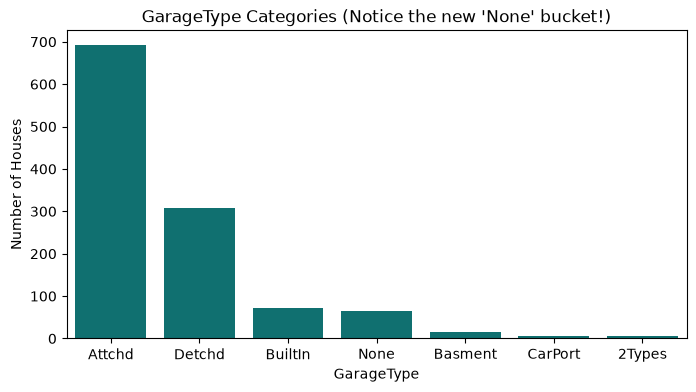

In [242]:
# --- 3.1 CATEGORICAL MNAR IMPUTATION ---
import matplotlib.pyplot as plt
import seaborn as sns

# List of categorical columns where NaN means 'Does Not Exist'
mnar_categorical = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
    'BsmtFinType2', 'MasVnrType'
]

# Fill NaN with 'None' in BOTH Train and Test sets
for col in mnar_categorical:
    X_train[col] = X_train[col].fillna('None')
    X_test[col] = X_test[col].fillna('None')

print("Categorical MNAR values successfully replaced with 'None'.")

# --- VISUALIZE THE RESULT ---
# Let's look at GarageType to see our newly created 'None' category in action
plt.figure(figsize=(8, 4))
sns.countplot(data=X_train, x='GarageType', order=X_train['GarageType'].value_counts().index, color='teal')
plt.title("GarageType Categories (Notice the new 'None' bucket!)")
plt.ylabel("Number of Houses")
plt.show()

### 3.2 Numerical MNAR: Fill with 0
For the numerical equivalents of these features (like the square footage of the garage, or the year it was built), a missing value also means the feature doesn't exist. 

Therefore, we don't impute the Median (which would give a house a phantom 400 sq ft garage). We simply impute `0`.

In [243]:
# --- 3.2 NUMERICAL MNAR IMPUTATION ---

# List of numerical columns where NaN means 'Does Not Exist' (zero)
mnar_numerical = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

# Fill NaN with 0 in BOTH Train and Test sets
for col in mnar_numerical:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

print("Numerical MNAR values successfully replaced with 0.")

# Verify by checking if any missing values remain in these columns
remaining_nulls = X_train[mnar_numerical].isnull().sum().sum()
print(f"Remaining nulls in numerical MNAR columns: {remaining_nulls}")

Numerical MNAR values successfully replaced with 0.
Remaining nulls in numerical MNAR columns: 0


> ⚠️ **WARNING: Calendar Years and Zeros**
> 
> Notice that we just filled `GarageYrBlt` with `0`. While `0` makes perfect mathematical sense for `GarageArea` (0 square feet), filling a Calendar Year with `0` is extremely dangerous (the year 0 A.D.). 
> 
> We are doing this temporarily to clear the `NaN` values, but we **must** remember to fix this broken calendar math later in the Feature Engineering phase, otherwise our models will fail!

## Step 4: MCAR Missing Value Strategy (Random Missingness)
We are now dealing with **Missing Completely At Random (MCAR)** data. These are genuine missing values where the surveyor simply forgot to record the data. The most prominent example in this dataset is `LotFrontage` (the linear feet of street connected to the property, missing ~17% of the time).

Before we blindly impute, let's look at the distribution of the feature to mathematically justify our choice of imputation.

In [244]:
# --- 4.0 VERIFY REMAINING MISSING VALUES ---
# Let's prove mathematically exactly what is left to fix.
missing = X_train.isnull().sum()
remaining_missing = missing[missing > 0]

print("=== REMAINING MISSING VALUES AFTER STEP 3 ===")
print(remaining_missing)

=== REMAINING MISSING VALUES AFTER STEP 3 ===
LotFrontage    217
Electrical       1
dtype: int64


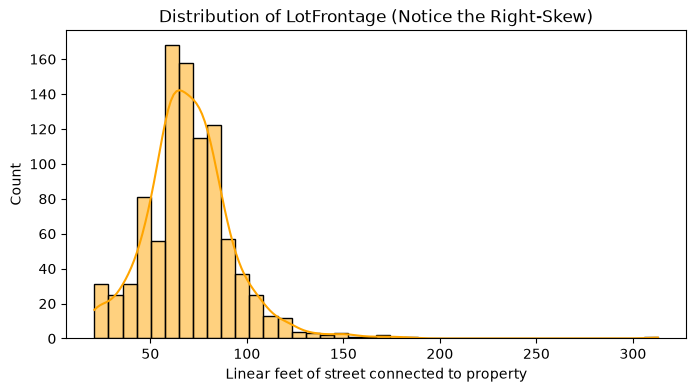

Mean of LotFrontage: 70.03
Median of LotFrontage: 70.00


In [245]:
# --- 4.1 VISUALIZE THE MCAR FEATURE ---
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(X_train['LotFrontage'].dropna(), kde=True, color='orange', bins=40)
plt.title("Distribution of LotFrontage (Notice the Right-Skew)")
plt.xlabel("Linear feet of street connected to property")
plt.show()

print(f"Mean of LotFrontage: {X_train['LotFrontage'].mean():.2f}")
print(f"Median of LotFrontage: {X_train['LotFrontage'].median():.2f}")

### Why we choose the Median (And why we group it)
**1. Why Median instead of Mean?**
As seen in the graph above, the data is positively skewed (a long tail to the right caused by a few massive properties). When data is skewed, the Mean is pulled artificially high by the outliers. The Median is robust to outliers, making it the mathematically correct choice.

**2. Why Group by Neighborhood?**
We could just fill all missing values with the global median (~70 feet). However, a house in a dense urban neighborhood naturally has a much smaller lot frontage than a house in a sprawling suburb. Therefore, we will fill the missing values with the median of *that specific house's Neighborhood*. This is a highly advanced, accurate imputation technique.

In [246]:
# --- 4.2 GROUPED MEDIAN IMPUTATION ---

# 1. Calculate the medians using ONLY the Training set (to prevent data leakage)
neighborhood_medians = X_train.groupby('Neighborhood')['LotFrontage'].median()

# 2. Fill the Training set
X_train['LotFrontage'] = X_train.apply(
    lambda row: neighborhood_medians[row['Neighborhood']] if pd.isnull(row['LotFrontage']) else row['LotFrontage'],
    axis=1
)

# 3. Fill the Test set (Applying the rule learned from Train!)
X_test['LotFrontage'] = X_test.apply(
    lambda row: neighborhood_medians[row['Neighborhood']] if pd.isnull(row['LotFrontage']) else row['LotFrontage'],
    axis=1
)

print("LotFrontage successfully imputed using Neighborhood medians.")
print(f"Remaining nulls in LotFrontage (Train): {X_train['LotFrontage'].isnull().sum()}")
print(f"Remaining nulls in LotFrontage (Test): {X_test['LotFrontage'].isnull().sum()}")

LotFrontage successfully imputed using Neighborhood medians.
Remaining nulls in LotFrontage (Train): 0
Remaining nulls in LotFrontage (Test): 0


### 4.3 Remaining Categorical MCAR: Impute with Mode
After handling the massive structural missingness (MNAR) and the complex LotFrontage missingness, there is exactly **1 missing value** left in our entire training dataset in the `Electrical` column.

Because it is just a single random error in a text category, we will simply fill it with the **Mode** (the most frequent category) from the training set.

Once this is done, we will run a final mathematical assertion to prove that our dataset is 100% clean.

In [247]:
# --- 4.3 CATEGORICAL MODE IMPUTATION & FINAL PROOF ---

# 1. Calculate the most frequent Electrical system in the Training set
electrical_mode = X_train['Electrical'].mode()[0]

# 2. Fill the missing value in Train and Test
X_train['Electrical'] = X_train['Electrical'].fillna(electrical_mode)
X_test['Electrical'] = X_test['Electrical'].fillna(electrical_mode)

print(f"Missing Electrical value filled with Mode: '{electrical_mode}'")
print("-" * 40)

# 3. THE FINAL PROOF
train_nulls = X_train.isnull().sum().sum()
test_nulls = X_test.isnull().sum().sum()

print("=== FINAL MISSING VALUE CHECK ===")
print(f"Total missing values in X_train: {train_nulls}")
print(f"Total missing values in X_test: {test_nulls}")

assert train_nulls == 0, "Wait, X_train still has missing data!"
assert test_nulls == 0, "Wait, X_test still has missing data!"
print("\nSUCCESS! We have mathematically proven that 100% of missing values have been successfully managed.")

Missing Electrical value filled with Mode: 'SBrkr'
----------------------------------------
=== FINAL MISSING VALUE CHECK ===
Total missing values in X_train: 0
Total missing values in X_test: 0

SUCCESS! We have mathematically proven that 100% of missing values have been successfully managed.


## Step 5: Drop Zero-Variance Columns (Automated Discovery)
A feature is only useful if it varies. If 99.9% of the houses have the exact same value for a feature, the algorithm cannot learn anything from it. 

Instead of hardcoding a list of columns to drop, we will write a dynamic scanner that mathematically proves which columns are useless by checking every single column in the dataset.

In [248]:
# --- 5.1 AUTOMATED ZERO-VARIANCE SCANNER ---

# We will scan every column. If > 99% of houses share the exact same value, we flag it.
columns_to_drop = []
threshold = 99.0

print("=== ZERO-VARIANCE DISCOVERY PROOF ===")
for col in X_train.columns:
    top_count = X_train[col].value_counts(dropna=False).iloc[0]
    percentage = (top_count / len(X_train)) * 100
    
    if percentage > threshold:
        print(f"FLAGGED: '{col}' ( {percentage:.2f}% of houses are identical ) ")
        columns_to_drop.append(col)

print("\nReady to drop:", columns_to_drop)

=== ZERO-VARIANCE DISCOVERY PROOF ===
FLAGGED: 'Street' ( 99.66% of houses are identical ) 
FLAGGED: 'Utilities' ( 99.91% of houses are identical ) 
FLAGGED: 'Condition2' ( 99.14% of houses are identical ) 
FLAGGED: 'PoolArea' ( 99.57% of houses are identical ) 
FLAGGED: 'PoolQC' ( 99.57% of houses are identical ) 

Ready to drop: ['Street', 'Utilities', 'Condition2', 'PoolArea', 'PoolQC']


In [249]:
# --- 5.2 EXECUTE DELETION ---

X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

print("=== AFTER DELETION ===")
print(f"Dynamically dropped {len(columns_to_drop)} columns.")
print(f"New X_train shape: {X_train.shape}")
print(f"New X_test shape: {X_test.shape}")

=== AFTER DELETION ===
Dynamically dropped 5 columns.
New X_train shape: (1166, 74)
New X_test shape: (292, 74)


## Step 6: Rare Category Grouping (The 'Other' Bucket)
During EDA, we discovered the Sparse Class (Rare Category) problem: dozens of text categories that only apply to 1, 2, or 3 houses (like a roof made of 'Metal').

If a category only appears once in the training data, the model will either memorize a false rule, or crash when it sees it during cross-validation. 

We will write a dynamic loop that scans all text columns, finds any category with fewer than 10 houses in the training set, and overwrites its name to `'Other'` in both datasets.

In [250]:
# --- 6.1 DISCOVER RARE CATEGORIES ---

categorical_features = X_train.select_dtypes(include=['object']).columns
rare_threshold = 10

# We will store the exact mapping of what needs to be changed
rare_mapping = {}

print("=== RARE CATEGORIES FOUND (<10 Houses) ===")
for col in categorical_features:
    counts = X_train[col].value_counts()
    rare_categories = counts[counts < rare_threshold].index.tolist()
    
    if len(rare_categories) > 0:
        rare_mapping[col] = rare_categories
        print(f"{col}: {rare_categories}")

print(f"\nFound rare categories in {len(rare_mapping)} different features.")

=== RARE CATEGORIES FOUND (<10 Houses) ===
MSZoning: ['C (all)']
LotShape: ['IR3']
LotConfig: ['FR3']
LandSlope: ['Sev']
Neighborhood: ['Veenker', 'NPkVill', 'Blueste']
Condition1: ['PosA', 'RRNn', 'RRNe']
HouseStyle: ['2.5Fin']
RoofStyle: ['Gambrel', 'Mansard', 'Shed']
RoofMatl: ['Tar&Grv', 'WdShngl', 'WdShake', 'Metal', 'Roll']
Exterior1st: ['BrkComm', 'ImStucc', 'CBlock', 'AsphShn', 'Stone']
Exterior2nd: ['ImStucc', 'Brk Cmn', 'AsphShn', 'Stone', 'Other', 'CBlock']
ExterCond: ['Ex', 'Po']
Foundation: ['Stone', 'Wood']
BsmtCond: ['Po']
Heating: ['Grav', 'Wall', 'OthW', 'Floor']
HeatingQC: ['Po']
Electrical: ['FuseP']
Functional: ['Maj1', 'Maj2', 'Sev']
GarageType: ['CarPort', '2Types']
GarageQual: ['Ex', 'Po']
GarageCond: ['Gd', 'Po', 'Ex']
Fence: ['MnWw']
MiscFeature: ['Othr', 'Gar2', 'TenC']
SaleType: ['ConLD', 'ConLI', 'ConLw', 'CWD', 'Oth', 'Con']
SaleCondition: ['Alloca', 'AdjLand']

Found rare categories in 25 different features.


/var/folders/4_/zfqf7kdn5c72dzy2gmbw98tw0000gn/T/ipykernel_1194/1066805629.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns


In [251]:
# --- 6.2 EXECUTE THE GROUPING ---

total_replacements = 0

for col, rare_categories in rare_mapping.items():
    total_replacements += len(rare_categories)
    # Replace the rare names with 'Other' in BOTH datasets
    X_train[col] = X_train[col].replace(rare_categories, 'Other')
    X_test[col] = X_test[col].replace(rare_categories, 'Other')

print("=== EXECUTION SUCCESS ===")
print(f"Successfully grouped {total_replacements} rare categories into 'Other' buckets.")

=== EXECUTION SUCCESS ===
Successfully grouped 63 rare categories into 'Other' buckets.


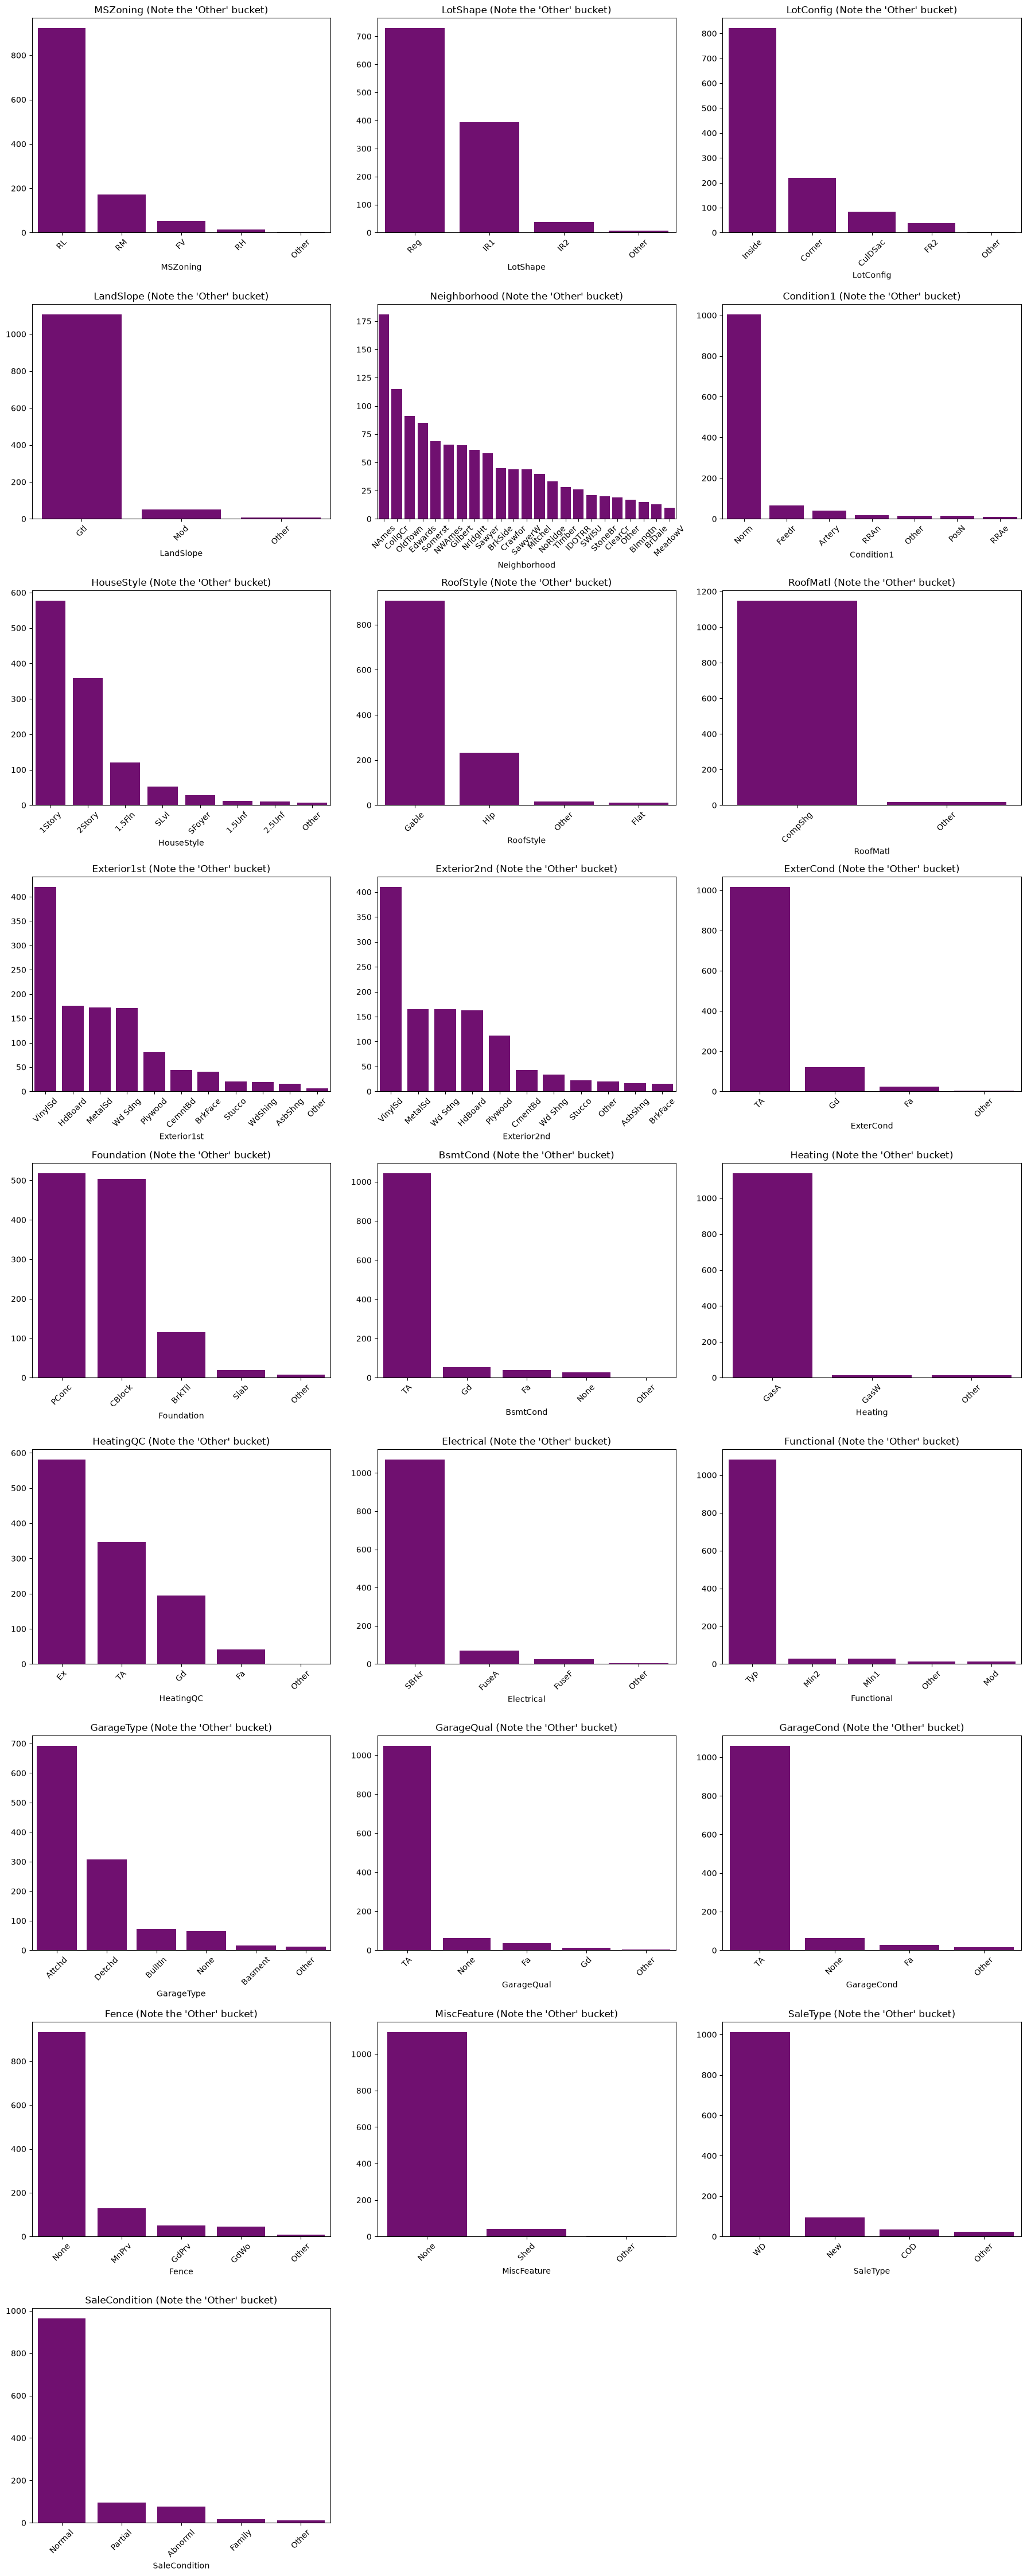

In [252]:
# --- 6.3 VISUALIZE THE FIX (ALL AFFECTED FEATURES) ---
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Grab only the features that actually had rare categories grouped
features_to_plot = list(rare_mapping.keys())

# Set up a large grid (3 graphs wide)
n_cols = 3
n_rows = math.ceil(len(features_to_plot) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

# Loop through all 25 features and plot them
for i, col in enumerate(features_to_plot):
    sns.countplot(data=X_train, x=col, order=X_train[col].value_counts().index, ax=axes[i], color='purple')
    axes[i].set_title(f"{col} (Note the 'Other' bucket)")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('')

# Hide any extra blank graphs at the bottom of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Step 7: Feature Engineering (Creating New Signal)
Machine Learning algorithms are not real estate agents. An algorithm does not inherently know that `1stFlrSF` + `2ndFlrSF` = `Total Square Footage`. 

By manually creating these composite features, we inject human domain knowledge directly into the math. 

**Features we will create:**
*   `TotalSF`: Combines basement, 1st, and 2nd floor square footage.
*   `TotalBath`: Combines full and half baths across all floors.
*   `HouseAge` & `RemodAge`: Calculates true age, and deletes the raw Calendar Years so they don't break our math.
*   `GarageAge`: Fixing the calendar year math and cleanly removing `GarageYrBlt`.

In [253]:
# --- 7. FEATURE ENGINEERING ---

def engineer_features(df):
    df = df.copy()
    
    # 1. Total Square Footage
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    
    # 2. Total Bathrooms (Half baths count as 0.5)
    df['TotalBath'] = (df['FullBath'] + (0.5 * df['HalfBath']) + 
                       df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))
    
    # 3. House Age & Remodel Age
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    
    # 4. Garage Age (Fixing the 2006-year-old math bug!)
    df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']
    df.loc[df['GarageYrBlt'] == 0, 'GarageAge'] = 0
    
    # 5. DROP REDUNDANT CALENDAR YEARS
    df = df.drop(columns=['YearBuilt', 'YearRemodAdd', 'GarageYrBlt'])
    
    return df

# Apply the exact same engineering to BOTH datasets
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

print("=== FEATURE ENGINEERING SUCCESS ===")
print(f"New X_train shape: {X_train.shape}")
print("New features added: TotalSF, TotalBath, HouseAge, RemodAge, GarageAge")
print("Redundant Calendar Years successfully dropped.")

=== FEATURE ENGINEERING SUCCESS ===
New X_train shape: (1166, 76)
New features added: TotalSF, TotalBath, HouseAge, RemodAge, GarageAge
Redundant Calendar Years successfully dropped.


## Step 7.5: Data Type Correction (The "Fake Numbers")


By reading the official `data_description.txt` file provided with the dataset, we discovered that `MSSubClass` is not a continuous number—it is a categorical barcode (e.g., `20` = 1-Story House). Similarly, `MoSold` and `YrSold` are calendar categories, not continuous measurements. 

If we leave them as integers, the automated mathematical scanner in Step 8 will violently transform them. We must cast them into text strings to protect them.

In [254]:
# --- 7.5 CAST TO STRING ---

fake_numbers = ['MSSubClass', 'MoSold', 'YrSold']

for col in fake_numbers:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print("=== DATA TYPE CORRECTION SUCCESS ===")
print(f"Protected {fake_numbers} by converting them to text strings.")

=== DATA TYPE CORRECTION SUCCESS ===
Protected ['MSSubClass', 'MoSold', 'YrSold'] by converting them to text strings.


## Step 8: Numerical Skewness Correction
Many of our continuous features (like `LotArea` and our new `TotalSF`) suffer from extreme right-skewness. 

Linear models (like Ridge Regression) assume data is normally distributed (a bell curve). Extreme outliers warp the regression line. Instead of deleting these valid luxury outliers, we mathematically shrink them using the **Yeo-Johnson Transformation**. Unlike a standard Log transform, Yeo-Johnson is mathematically safe to use on columns containing zeros (like `PoolArea` or `Fireplaces`).

In [255]:
# --- 8.1 DISCOVER SKEWED FEATURES ---

# 1. Find all numerical features
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# 2. Calculate their skewness
skewness = X_train[numeric_cols].apply(lambda x: x.skew())

# 3. Filter for highly skewed features (> 0.75 or < -0.75)
skewed_features = skewness[abs(skewness) > 0.75].index.tolist()

print(f"=== FOUND {len(skewed_features)} HIGHLY SKEWED FEATURES ===")
print("These features have extreme tails (like massive wooden decks) and need mathematical compression to protect the linear models:")
print(skewed_features)

=== FOUND 18 HIGHLY SKEWED FEATURES ===
These features have extreme tails (like massive wooden decks) and need mathematical compression to protect the linear models:
['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MiscVal', 'TotalSF']


In [256]:
# --- 8.2 APPLY YEO-JOHNSON TRANSFORMATION ---
from sklearn.preprocessing import PowerTransformer

# Save the ORIGINAL un-transformed data for ALL skewed features so we can plot them later
original_skewed_df = X_train[skewed_features].copy()

# Initialize the Transformer (standardize=False because we will do full scaling in Step 10)
pt = PowerTransformer(method='yeo-johnson', standardize=False)

# Fit ONLY on X_train to prevent data leakage
pt.fit(X_train[skewed_features])

# Transform BOTH datasets
X_train[skewed_features] = pt.transform(X_train[skewed_features])
X_test[skewed_features] = pt.transform(X_test[skewed_features])

print("=== YEO-JOHNSON TRANSFORMATION SUCCESSFUL ===")
print("Massive outliers have been mathematically shrunk into normal distributions.")

=== YEO-JOHNSON TRANSFORMATION SUCCESSFUL ===
Massive outliers have been mathematically shrunk into normal distributions.


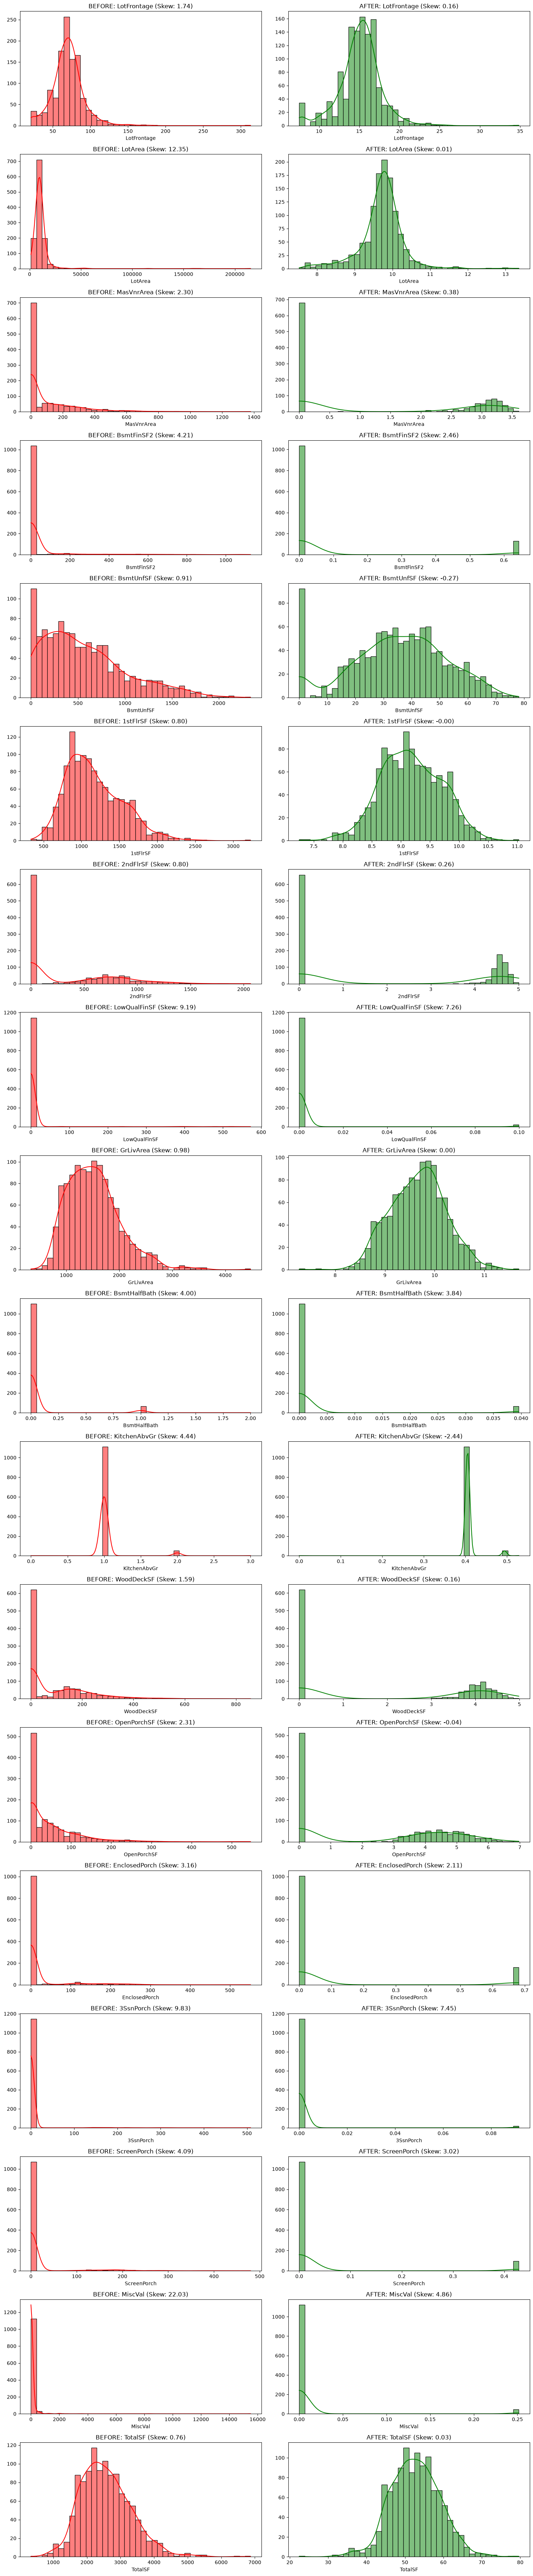

In [257]:
# --- 8.3 VISUALIZE THE FIX (ALL SKEWED FEATURES) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a Before/After grid for every single transformed feature
num_features = len(skewed_features)
fig, axes = plt.subplots(nrows=num_features, ncols=2, figsize=(15, 4 * num_features))

for i, col in enumerate(skewed_features):
    # BEFORE Plot (Red)
    sns.histplot(original_skewed_df[col].dropna(), kde=True, ax=axes[i, 0], color='red', bins=40)
    orig_skew = original_skewed_df[col].skew()
    axes[i, 0].set_title(f'BEFORE: {col} (Skew: {orig_skew:.2f})')
    axes[i, 0].set_ylabel('')
    
    # AFTER Plot (Green)
    sns.histplot(X_train[col].dropna(), kde=True, ax=axes[i, 1], color='green', bins=40)
    new_skew = X_train[col].skew()
    axes[i, 1].set_title(f'AFTER: {col} (Skew: {new_skew:.2f})')
    axes[i, 1].set_ylabel('')

plt.tight_layout()
plt.show()

## Step 9: Categorical Encoding (Words to Numbers)
Machine Learning algorithms cannot read text like `"Excellent"` or `"Gable"`. We must convert all remaining text into numbers.

We split this into two strategies:
1.  **Ordinal Encoding:** For text that has a strict hierarchy (e.g., Excellent > Good > Poor). We manually map these to numbers (5 > 4 > 1) to preserve the mathematical value.
2.  **One-Hot Encoding:** For text that has no mathematical order (e.g., Roof Style, Neighborhood, and the `MSSubClass` we rescued earlier). We convert these into multiple binary Yes/No (`1` or `0`) columns.

In [258]:
# --- 9.1 ORDINAL ENCODING (Manual Mapping) ---
import pandas as pd

# The standard 1-5 quality scale
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
             'KitchenQual', 'GarageQual', 'GarageCond', 'FireplaceQu']

for col in qual_cols:
    X_train[col] = X_train[col].map(qual_map)
    X_test[col] = X_test[col].map(qual_map)

# Custom Mappings based on the Data Dictionary
bsmt_exp_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
garage_fin_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
shape_map = {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4}
slope_map = {'Sev': 1, 'Mod': 2, 'Gtl': 3}
func_map = {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}

X_train['BsmtExposure'] = X_train['BsmtExposure'].map(bsmt_exp_map)
X_test['BsmtExposure'] = X_test['BsmtExposure'].map(bsmt_exp_map)
X_train['BsmtFinType1'] = X_train['BsmtFinType1'].map(bsmt_fin_map)
X_test['BsmtFinType1'] = X_test['BsmtFinType1'].map(bsmt_fin_map)
X_train['BsmtFinType2'] = X_train['BsmtFinType2'].map(bsmt_fin_map)
X_test['BsmtFinType2'] = X_test['BsmtFinType2'].map(bsmt_fin_map)
X_train['GarageFinish'] = X_train['GarageFinish'].map(garage_fin_map)
X_test['GarageFinish'] = X_test['GarageFinish'].map(garage_fin_map)
X_train['LotShape'] = X_train['LotShape'].map(shape_map)
X_test['LotShape'] = X_test['LotShape'].map(shape_map)
X_train['LandSlope'] = X_train['LandSlope'].map(slope_map)
X_test['LandSlope'] = X_test['LandSlope'].map(slope_map)
X_train['Functional'] = X_train['Functional'].map(func_map)
X_test['Functional'] = X_test['Functional'].map(func_map)

print("=== 9.1 ORDINAL ENCODING COMPLETE ===")

=== 9.1 ORDINAL ENCODING COMPLETE ===


In [259]:
# --- 9.2 ONE-HOT ENCODING (Nominal Categories) ---

# Convert all remaining text columns into binary Yes/No columns (0 or 1)
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# ALIGNMENT: Ensure Train and Test have the exact same columns after One-Hot Encoding
# If a rare category existed in Train but not Test, this adds it to Test with 0s.
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("=== 9.2 ONE-HOT ENCODING COMPLETE ===")
print(f"Final X_train shape after encoding: {X_train.shape}")

=== 9.2 ONE-HOT ENCODING COMPLETE ===
Final X_train shape after encoding: (1166, 214)


## Step 10: Feature Scaling
Our data is clean, transformed, and encoded. But the scales are wildly different (`TotalSF` is in the thousands, while `TotalBath` is around 2). 

Linear Regression and SVR models will falsely assume `TotalSF` is a thousand times more important just because the number is larger. We use `StandardScaler` to shrink/stretch every single column so they all have a Mean of `0` and a Standard Deviation of `1`. 

> **The Golden Rule:** We fit the scaler strictly on `X_train`, and transform both.

In [260]:
# --- 10. FEATURE SCALING ---
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialize the Scaler
scaler = StandardScaler()

# 1. FIT the scaler ONLY on X_train (Learn the mean and variance)
scaler.fit(X_train)

# Save a copy of the unscaled data for visualization
X_train_unscaled = X_train.copy()

# 2. TRANSFORM both datasets
# (StandardScaler returns numpy arrays, so we wrap them back into pandas DataFrames to keep our column names!)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("=== FEATURE SCALING COMPLETE ===")
print("Every feature is now perfectly balanced on the same numerical scale.")

=== FEATURE SCALING COMPLETE ===
Every feature is now perfectly balanced on the same numerical scale.


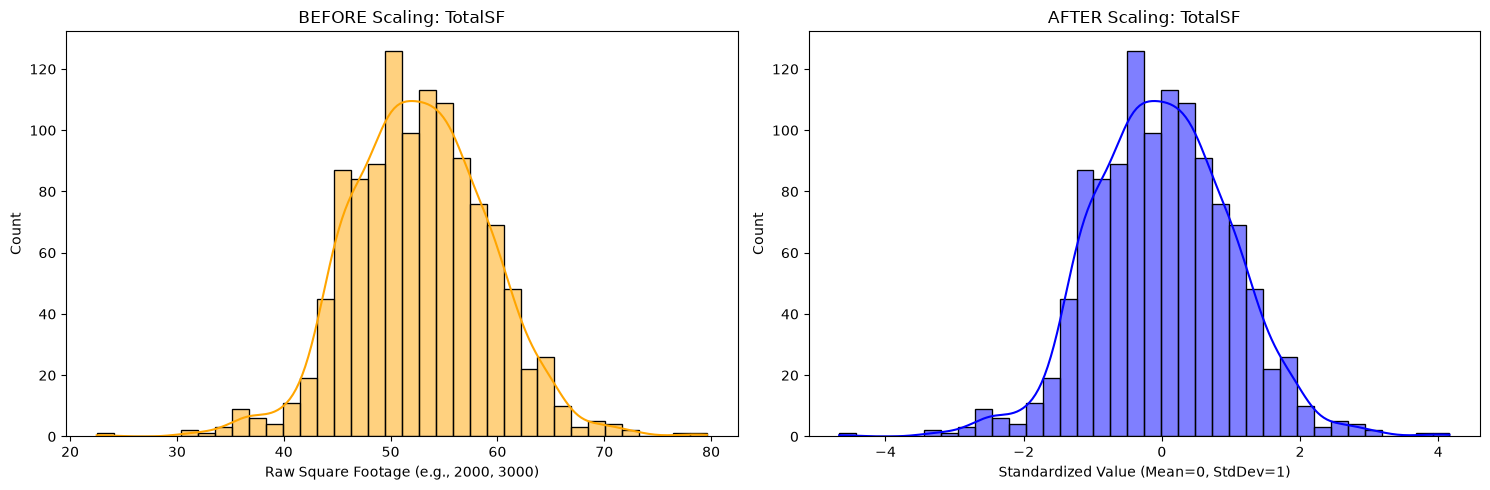

=== MATHEMATICAL PROOF ===
BEFORE Mean: 52.69 sq ft, StdDev: 6.47
AFTER  Mean: -0.00, StdDev: 1.00


In [261]:
# --- 10.1 VISUALIZE THE SCALING ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

feature_to_plot = 'TotalSF'

# BEFORE Scaling
sns.histplot(X_train_unscaled[feature_to_plot], kde=True, ax=axes[0], color='orange')
axes[0].set_title(f"BEFORE Scaling: {feature_to_plot}")
axes[0].set_xlabel("Raw Square Footage (e.g., 2000, 3000)")

# AFTER Scaling
sns.histplot(X_train_scaled[feature_to_plot], kde=True, ax=axes[1], color='blue')
axes[1].set_title(f"AFTER Scaling: {feature_to_plot}")
axes[1].set_xlabel("Standardized Value (Mean=0, StdDev=1)")

plt.tight_layout()
plt.show()

print("=== MATHEMATICAL PROOF ===")
print(f"BEFORE Mean: {X_train_unscaled[feature_to_plot].mean():.2f} sq ft, StdDev: {X_train_unscaled[feature_to_plot].std():.2f}")
print(f"AFTER  Mean: {X_train_scaled[feature_to_plot].mean():.2f}, StdDev: {X_train_scaled[feature_to_plot].std():.2f}")

## Step 11: Export the Gold Standard Dataset
We have successfully traversed the entire preprocessing pipeline without a single data leak. 

We will now save our pristine `X_train_scaled`, `X_test_scaled`, `y_train`, and `y_test` datasets to CSV files so we can load them directly into our Modeling notebooks.

In [262]:
# --- 11. SAVE PREPROCESSED DATA ---
import os

# Create the processed data folder if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Save the DataFrames to CSV
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)

y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("=== PIPELINE COMPLETE ===")
print("Data successfully saved to /data/processed/")
print("We are ready to build the Machine Learning models!")

=== PIPELINE COMPLETE ===
Data successfully saved to /data/processed/
We are ready to build the Machine Learning models!
